In [1]:
# importar librerías
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [10]:

# cantidad de nulos para users
print("Cantidad de valores nulos: ", users.isna().sum())
print("Proporción de valores nulos: ", users.isna().mean())


Cantidad de valores nulos:  user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos:  user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos: ", usage.isna().sum())
print("Proporción de valores nulos: ", usage.isna().mean())

Cantidad de valores nulos:  id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos:  id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


- La columnas churn_date, duration y length muestran valores altos de nulos. La primera sobrepasa el 90%, por lo que se podría ignorar o eliminar. Mientras tanto, las otras dos columnas podrían ser rellenadas con la media o mediana. 

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se ve estable y concisa, sin sesgos. 
- La columna `age` demuestra que el público es uno maduro y objetivo. 

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran la misma cantidad de registros, mientras las otras dos columnas no lo hacen. 
- Las columnas `duration` y `length` muestran un sesgo hacia la derecha, además del sospechoso valor 0 como mínima. 

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Columna {col}:")
    print(users.info())

Columna city:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None
Columna plan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 n

- La columna `city` muestra concistencia y se podría hacer doble click sobre qué ciudades tienen más peso. 
- La columna `plan` también se muestra estable, sin valores faltantes, y de aquí podría salir información sobre el comportamiento de los usuarios. 

In [15]:
# explorar columna categórica de usage
# Información básica de la columna
print("Tipo de datos:", usage['type'].dtype)
print("Valores únicos:", usage['type'].nunique())
print("Valores nulos:", usage['type'].isnull().sum())

# Conteo de cada categoría
print("\nConteo por categoría:")
print(usage['type'].value_counts())

# Descripción estadística
print("\nDescripción:")
print(usage['type'].describe())

Tipo de datos: object
Valores únicos: 2
Valores nulos: 0

Conteo por categoría:
text    22092
call    17908
Name: type, dtype: int64

Descripción:
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` se divide en 2 valores únicos y posee un conteo igual al de user_id. 


- 'duration' y 'length' no poseen valores faltantes ya que coinciden con los valores de 'call' y 'text'.
- El 55% de las comunicaciones se hacen por mensaje ('text'), mientras el 45% es por llamada ('call')
- Hay cero valores nulos. 

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

En `reg_date` explora el año 2018 completo. También muestra que durante 95 días no se registró nadie. Por último, no debieron haber campañas de marketing grandes ya que el top de registros es muy bajo (8).

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()

count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

En `date` muestra una actividad más reciente (2024). El count aquí es menor que los resultados anteriores, por lo que deduzco que faltan 50 registros. 

- Recomiendo idenditificar aquellos usuarios que ya llevan varios años con la compañía, como los que comienzan en 2018 y muestran actividad en el 2024.
- También se podría hacer un análisis para buscar fechas imposibles como alguien con actividad antes de su enrolamiento. 

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
from datetime import datetime
import numpy as np

# Obtener la fecha actual
fecha_actual = datetime.now()

# Marcar fechas futuras como NA
users.loc[users['reg_date'] > fecha_actual, 'reg_date'] = np.nan

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Duration muestra nulos en textos, mientras length lo hace en llamadas. Esto indica que se trata de un MAR estructurado, es decir que depende por completo de type. 

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario y renombrar columnas
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",       
    "is_call": "sum",       
    "duration": "sum"       
    }).rename(columns={"is_text":"cant_mensajes"
                       ,"is_call":"cant_llamadas"
                       ,"duration":"cant_minutos_llamada"}).reset_index()

# Combinar esta tabla con la tabla de usuarios (users)
usage_final = users.merge(usage_agg, on="user_id", how="left")
usage_activos = usage_final.dropna(subset=['cant_minutos_llamada', 'cant_mensajes'])

# Observar resultado
print(usage_agg.head(3))

   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74


In [26]:
# Rellenamos los NaN con 0 para poder calcular la mediana y el resumen
columnas_consumo = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Resumen estadístico de las columnas numéricas
print("--- Resumen Estadístico de Columnas Numéricas ---")
for col in columnas_consumo:
    mediana_sin_nan = usage_final[col].median()  # antes del fillna
    print(f"Mediana de {col}: {mediana_sin_nan}")
print(usage_final[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

--- Resumen Estadístico de Columnas Numéricas ---
Mediana de age: 47.0
Mediana de cant_mensajes: 5.0
Mediana de cant_llamadas: 4.0
Mediana de cant_minutos_llamada: 19.78
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.122250       5.524381       4.478120             23.317054
std      17.690408       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [27]:
# Distribución porcentual del tipo de plan
print("\n--- Distribución de Planes (Tarifas) en % ---")
distribucion_planes = usage_final['plan'].value_counts(normalize=True) * 100
print(distribucion_planes.map("{:.2f}%".format))


--- Distribución de Planes (Tarifas) en % ---
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


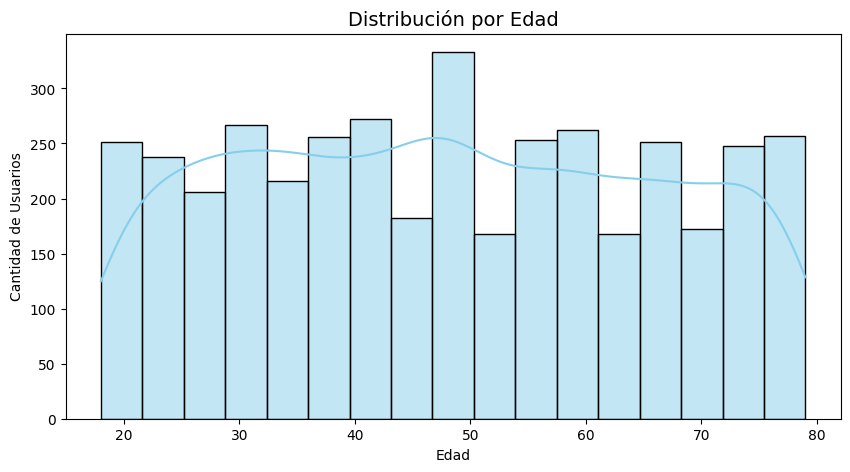

In [28]:
# Histograma para visualizar por edad

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(data=usage_final, x='age', color="skyblue", kde=True)
plt.title('Distribución por Edad', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- La distribución por edad muestra un promedio entre 45 y 50 años.
- El público de los planes es maduro y económicamente independientes. 

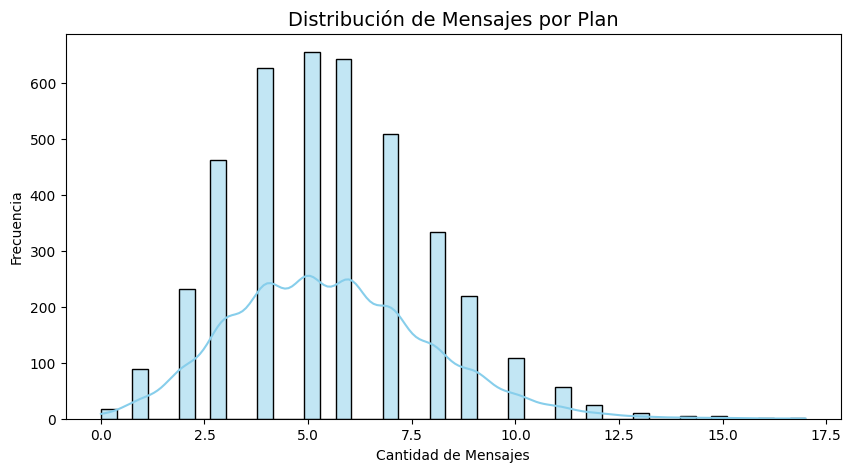

In [29]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=usage_final, x='cant_mensajes', color="skyblue", kde=True)
plt.title('Distribución de Mensajes por Plan', fontsize=14)
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La cantidad de mensajes mayores se hacen uno tras otro.
- Una frecuencia alta significa que hay un gran poder de retención de la atención de los usuarios. 

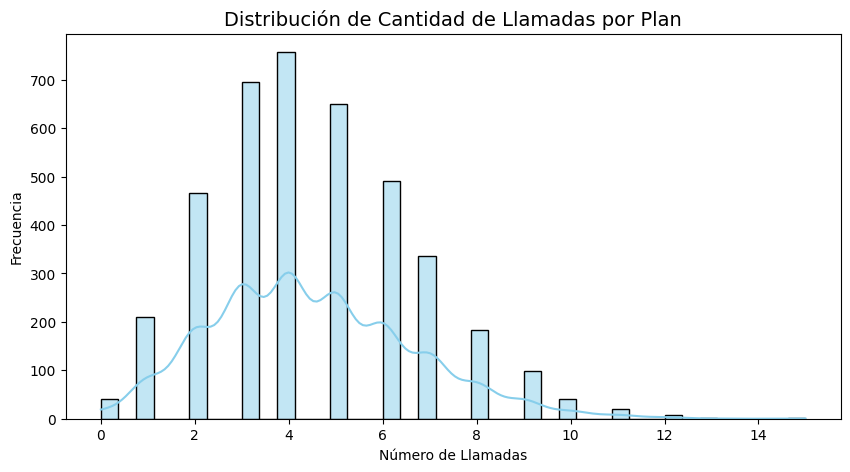

In [30]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=usage_final, x='cant_llamadas',color="skyblue", kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan', fontsize=14)
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de llamadas nos podría arrojar más información si tuviésemos el rango de horario en el que ocurren.
- Esto podría decantar en una campaña de marketing enfocada en ese espacio. 

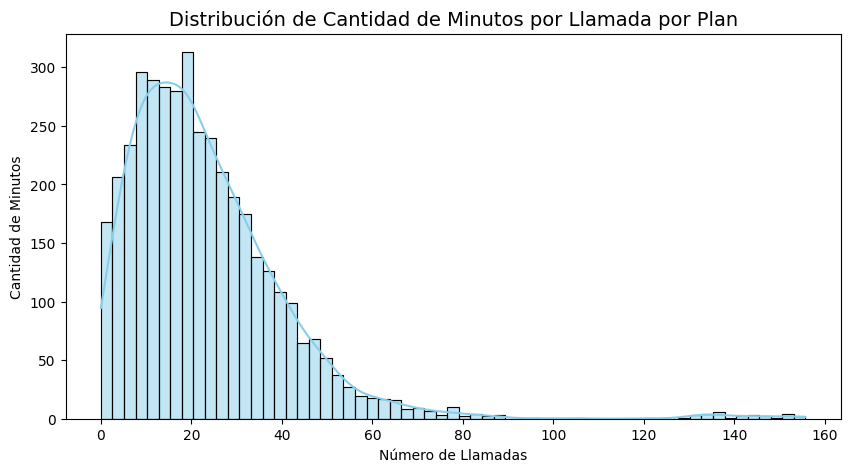

In [31]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=usage_final, x='cant_minutos_llamada',color="skyblue", kde=True)
plt.title('Distribución de Cantidad de Minutos por Llamada por Plan', fontsize=14)
plt.xlabel('Número de Llamadas')
plt.ylabel('Cantidad de Minutos')
plt.show()

💡Insights: 
- Si bien son pocas llamadas para lo que podrían ser, su duración es larga en la mayoría de los casos. 

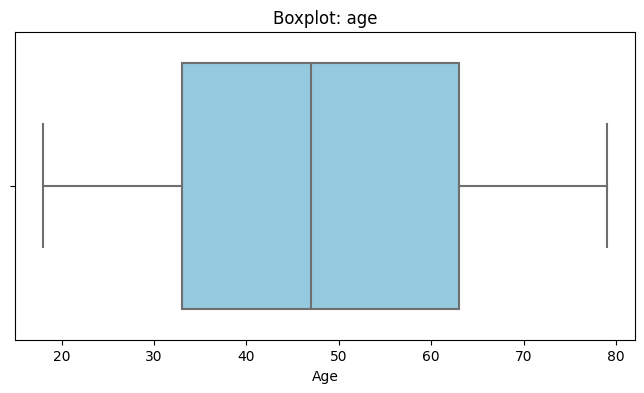

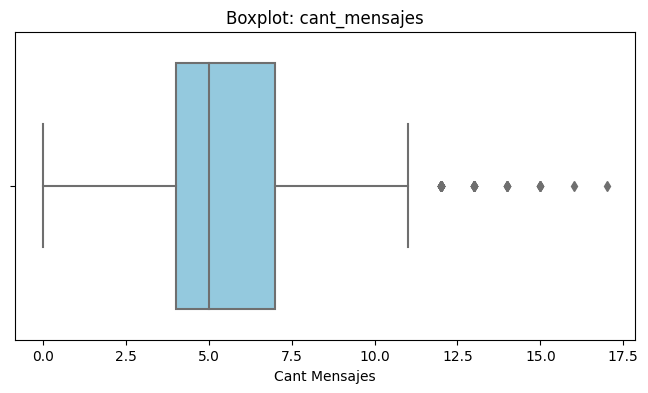

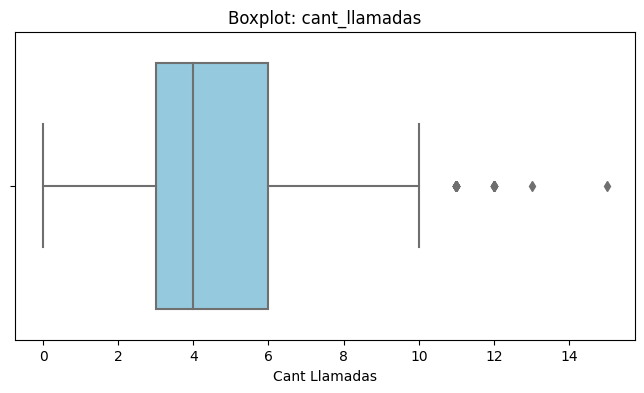

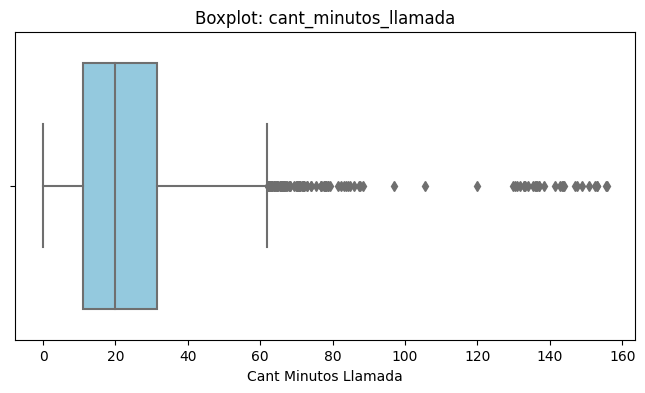

In [32]:
# Visualizando usando BoxPlot 
import seaborn as sns
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=usage_final[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col.replace('_', ' ').title())
    plt.show()

💡Insights: 
- Age: No presenta outliers. 
- cant_mensajes: Presenta 6 outliers. 
- cant_llamadas: Presenta 4 outliers. 
- cant_minutos_llamada: Presenta varios outliers. 

In [33]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(f"Análisis de Límites Superiores (IQR)")

for col in columnas_limites: 
    Q1 = usage_final[col].quantile(0.25)
    Q3 = usage_final[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    # Contamos cuántos outliers hay
    cant_outliers = len(usage_final[usage_final[col] > limite_superior])
    
    print(f"Columna: {col}")
    print(f"Límite Superior: {limite_superior:.2f}")
    print(f"Cantidad de outliers detectados: {cant_outliers}")
    print("-" * 40)

Análisis de Límites Superiores (IQR)
Columna: cant_mensajes
Límite Superior: 11.50
Cantidad de outliers detectados: 46
----------------------------------------
Columna: cant_llamadas
Límite Superior: 10.50
Cantidad de outliers detectados: 30
----------------------------------------
Columna: cant_minutos_llamada
Límite Superior: 61.86
Cantidad de outliers detectados: 109
----------------------------------------


In [34]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
usage_final[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes y cant_llamadas parecen ser consistentes por lo que los mantendría (el máximo y el 75% de la actividad se acercan mucho).
- cant_minutos_llamada presenta llamadas con hasta 155 minutos, lo que indica que podría haber un error en la conexión/quedó el teléfono descolgado, o en serio se trata de Heavy Users. 

In [35]:

# Función con lógica de segmentación
def segmentar_usuario(fila):
    llamadas = fila['cant_llamadas']
    mensajes = fila['cant_mensajes']
    
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Creación del grupo_uso
usage_final['grupo_uso'] = usage_final.apply(segmentar_usuario, axis=1)

# 3. Verificamos el resultado
print(usage_final['grupo_uso'].value_counts())


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [36]:
# verificar cambios
usage_final.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [37]:
# Función con lógica de segmentación
def segmentar_edad(fila):
    edad = fila['age']
    
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Creación del grupo_uso
usage_final['grupo_edad'] = usage_final.apply(segmentar_edad, axis=1)

# 3. Verificamos el resultado
print(usage_final['grupo_edad'].value_counts())


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [38]:
# verificar cambios
usage_final.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


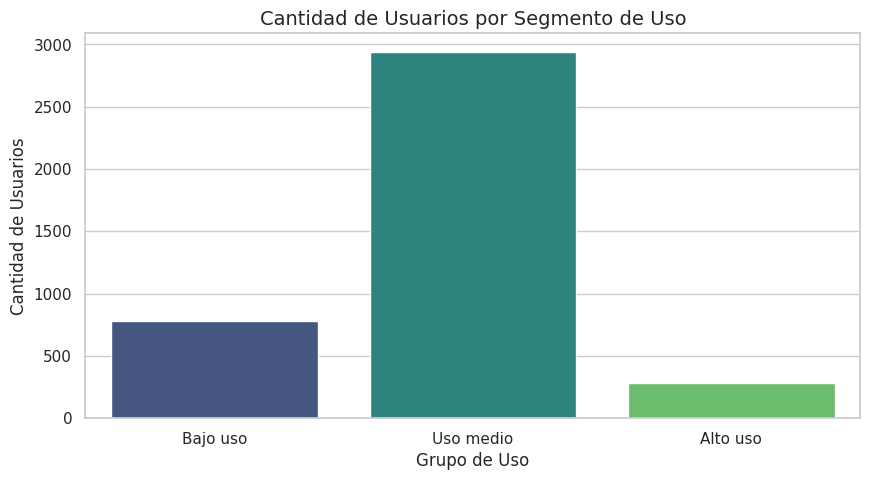

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Distribución por Grupo de Uso 
plt.figure(figsize=(10, 5))
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
sns.countplot(data=usage_final, x='grupo_uso', order=orden_uso, palette='viridis')

plt.title('Cantidad de Usuarios por Segmento de Uso', fontsize=14)
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

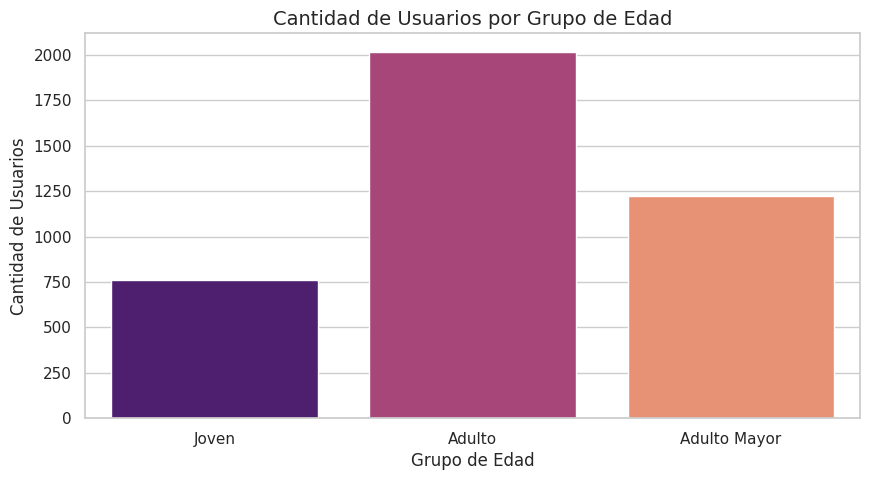

In [40]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10, 5))
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
sns.countplot(data=usage_final, x='grupo_edad', order=orden_edad, palette='magma')

plt.title('Cantidad de Usuarios por Grupo de Edad', fontsize=14)
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

**Análisis ejecutivo**

⚠️ **Calidad de Datos y Hallazgos Técnicos**
- Problema: Las columnas de consumo (duration y length) tenían vacíos masivos.
- Realidad: No eran datos perdidos, sino variables exluyentes. El 55% de las filas correspondían a mensajes (sin duración de voz) y el 45%, a llamadas (sin longitud de texto). Esto hace 100% íntegro al sistema de registro. 


🔍 **Segmentación por Edad y Uso**
- Identificamos tres perfiles claros:
     a) Usuario "Light" (Adulto Mayor) - Comportamiento estable y suelen tener planes básicos.
     b) "Core" del Negocio (Adulto) - Uso medio, equilibrando llamadas y mensajes.
     c) "Power Users" (Jóvenes) - Aunque son menos en cantidad, generan mayor tráfico de red, especialmente en mensajería. 


➡️ Esto sugiere que el segmento más valioso es el Adulto de Uso Medio, por su volumen y estabilidad. Sin embargo, el segmento con mayor potencial de crecimiento es el de los Jóvenes de Alto Uso, siendo candidatos para estrategias de upselling. 


💡 **Recomendaciones**
- Crear una oferta simplificada para los Adultos Mayores, enfocados en confiabilidad sobre volumen.
- Plan con mensajes ilimitados para jóvenes, pero con minutos controlados.
- Implementar alertas de consumo para usuarios que superan los límites del IQR (como los 155 minutos) para ofrecerles paquetes customizados o planes verdaderamente ilimitados. 

Link a repositorio público del proyecto: `https://github.com/YadsN/telecom-analysis`